In [ ]:
RANDOM FORESTS

Data Loaded: (1423, 21)
Generating Exploratory Visualization...


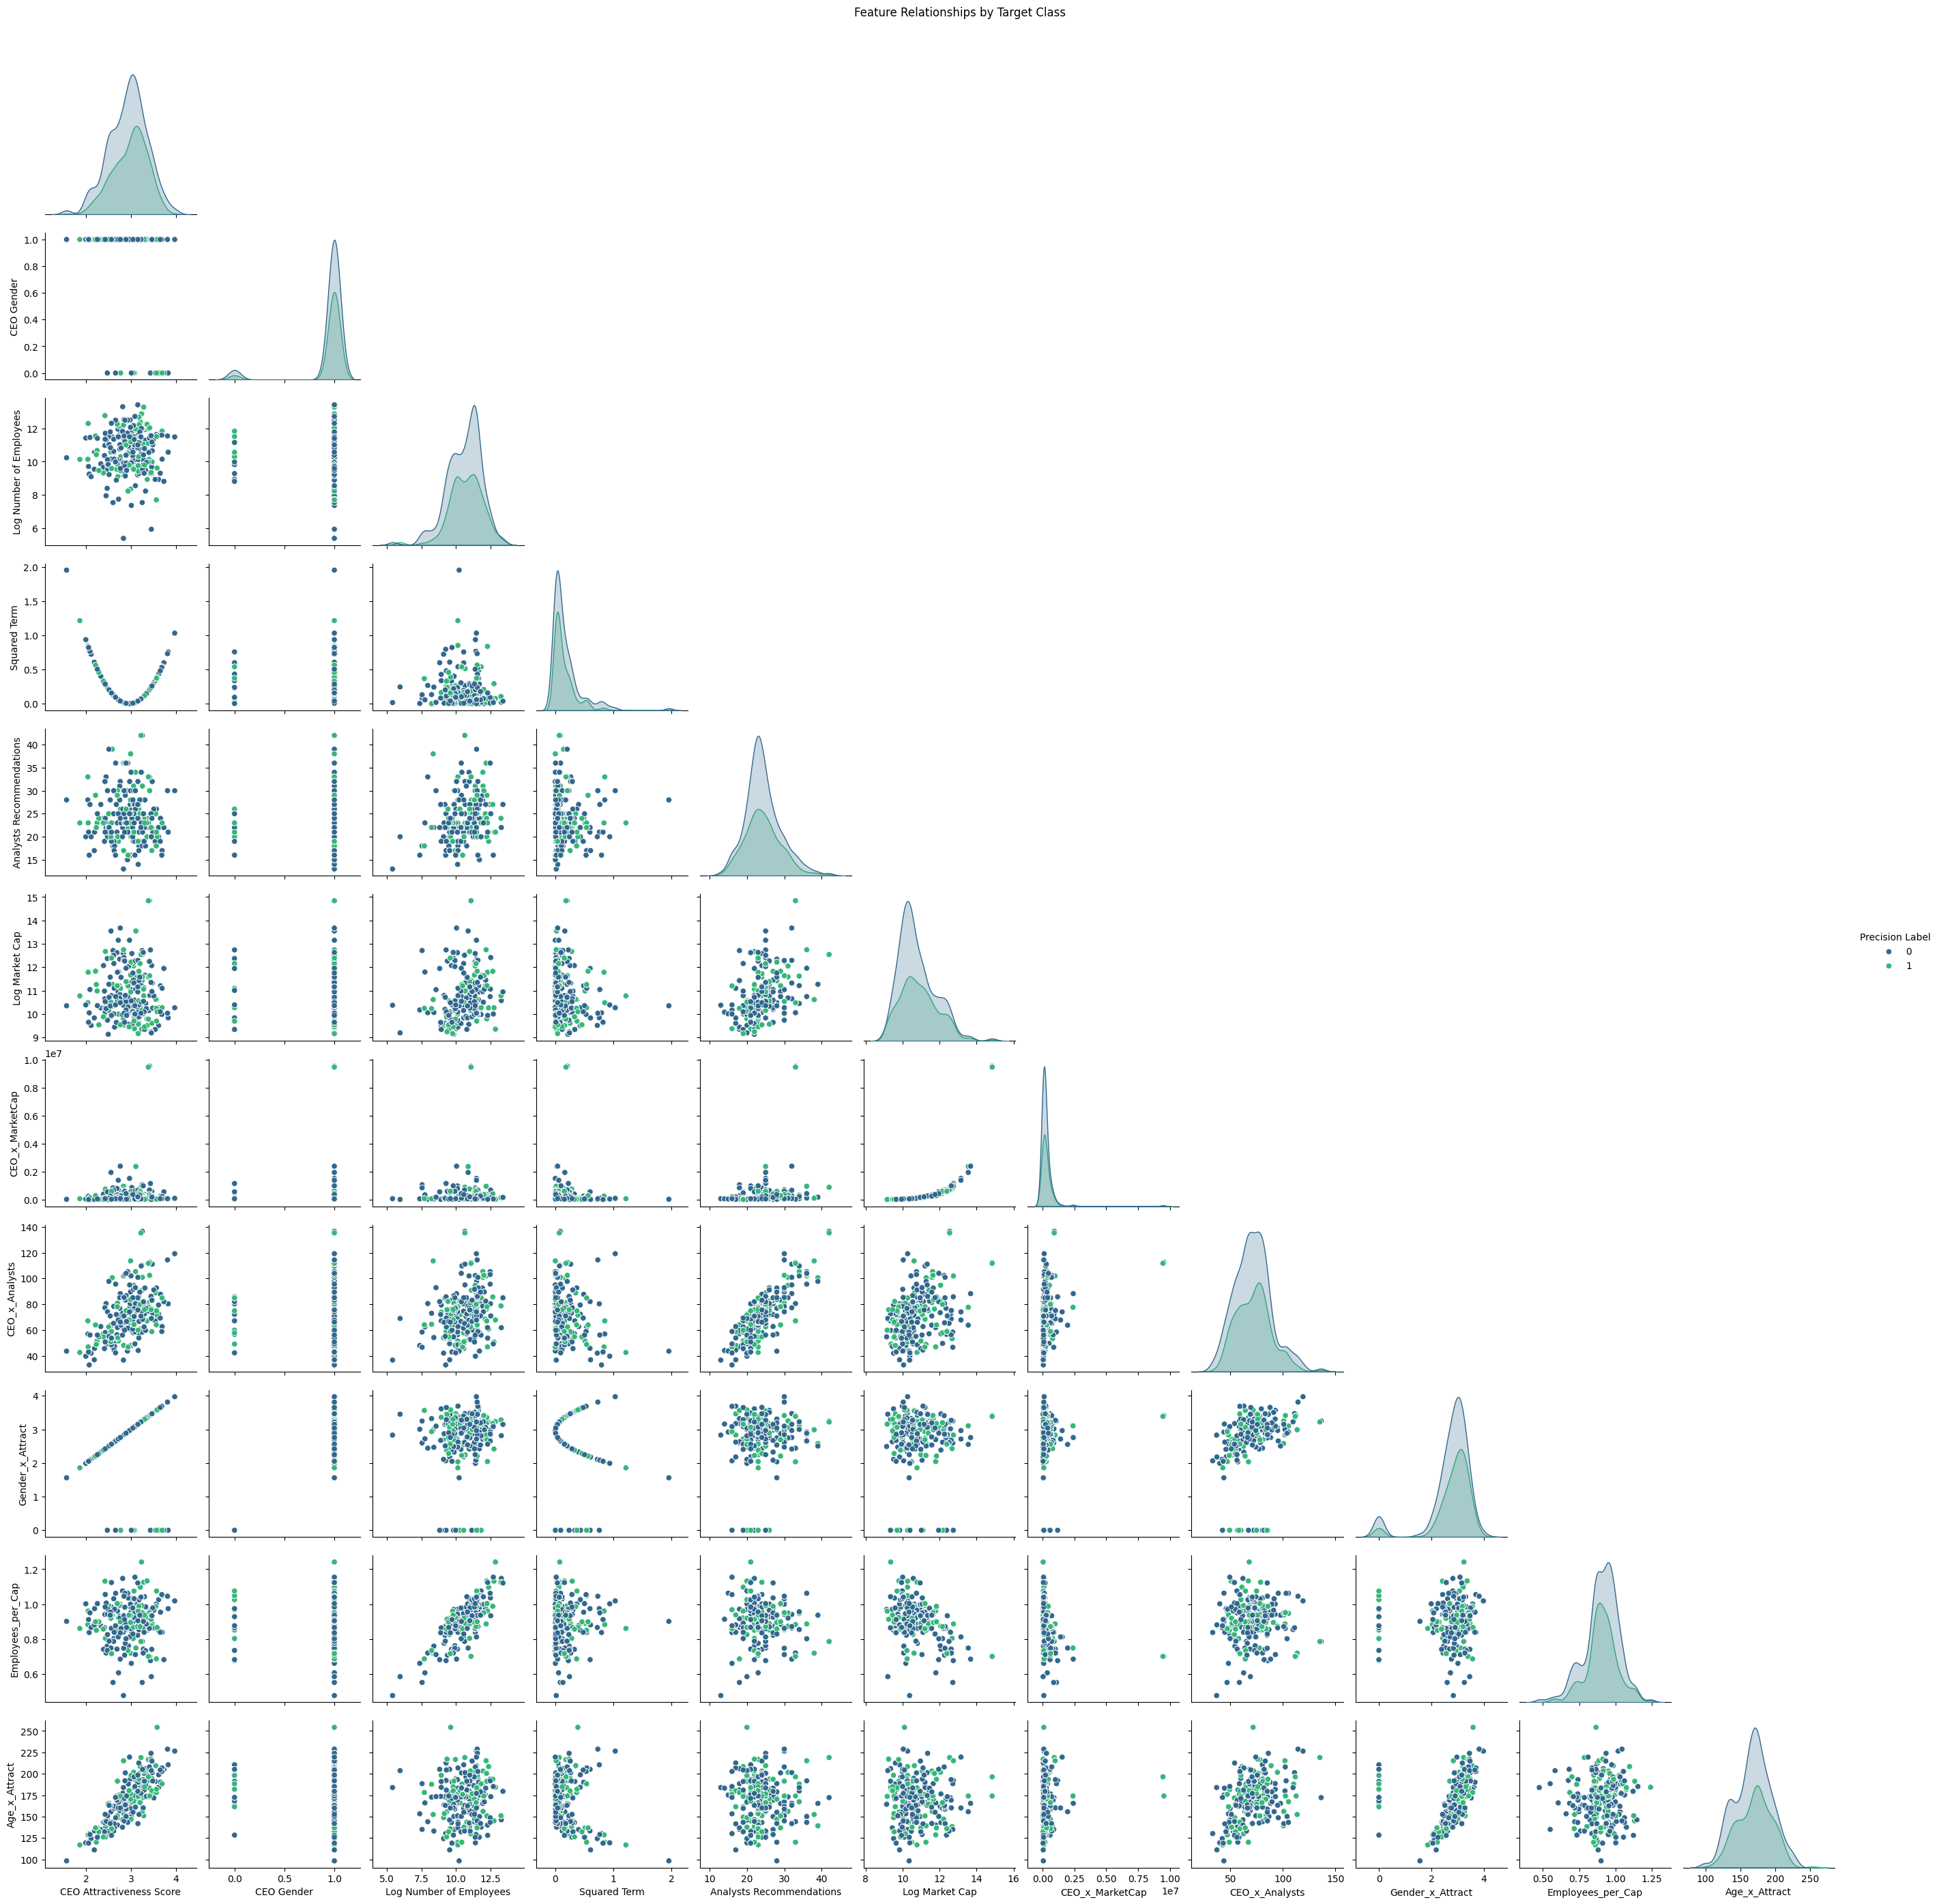

Applying SMOTE to training data...
Original training set shape: (1138, 11), (1138,)
SMOTE-resampled training set shape: (1454, 11), (1454,)
Reloading Tuner from my_dir/ceo_classification_tuning/tuner0.json

--- Starting Hyperparameter Search ---

Optimal Units (Layer 0): 128
Optimal Learning Rate: 0.005820326357694492

--- Training Final Model with Best Hyperparameters ---
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - AUC: 0.4836 - accuracy: 0.5711 - loss: 0.6989 - val_AUC: 0.0000e+00 - val_accuracy: 0.0550 - val_loss: 0.8881
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.5247 - accuracy: 0.6185 - loss: 0.6695 - val_AUC: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 1.0366
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.5333 - accuracy: 0.6190 - loss: 0.6687 - val_AUC: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.8732
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.5887 - accuracy: 0.6332 - loss: 0.6483 - val_AUC: 0.0000e+00 - val_acc

/tmp/ipython-input-281765941.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lift_table.index, y='Lift', data=lift_table, ax=axes[0], palette="Blues_r")


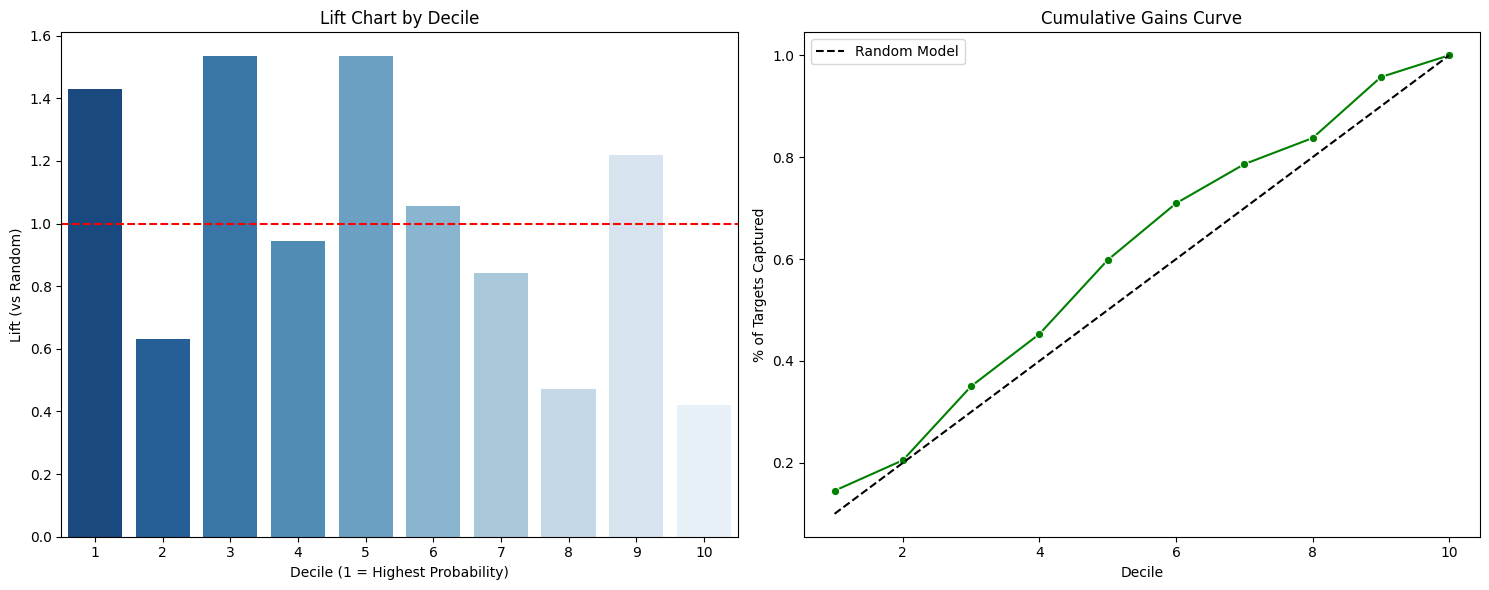

In [ ]:
!pip install keras-tuner seaborn matplotlib imblearn
import pandas as pd
import numpy as np
import tensorflow as tf
import keras_tuner as kt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE # Import SMOTE

# --- 1. Load Data ---
# Ensure 'exportv4.csv' is in your directory
try:
    df = pd.read_csv('exportv8.csv', sep=';')
    print(f"Data Loaded: {df.shape}")
except FileNotFoundError:
    print("Error: 'exportv6.csv' not found. Please ensure the file exists.")
    # For demonstration, uncomment below to generate dummy data if file is missing
    # df = pd.DataFrame(np.random.randn(1000, 4), columns=['CEO Attractiveness Score', 'Squared Term', 'Analysts Recommendations', 'Log Market Cap'])
    # df['Big Error on % -'] = np.random.randint(0, 2, 1000)
    exit()

# --- 2. Visualization: Relationship Analysis ---
# Visualizing features relative to the target label
print("Generating Exploratory Visualization...")
features = ['CEO Attractiveness Score', 'CEO Gender', 'Log Number of Employees', 'Squared Term',
            'Analysts Recommendations',  'Log Market Cap', 'Age']
# Create interaction features
df['CEO_x_MarketCap'] = df['CEO Attractiveness Score'] * df['Market Cap Avg']
df['CEO_x_Analysts'] = df['CEO Attractiveness Score'] * df['Analysts Recommendations']
df['Gender_x_Attract'] = df['CEO Gender'] * df['CEO Attractiveness Score']
df['Employees_per_Cap'] = df['Log Number of Employees'] / (df['Log Market Cap'] + 1)
df['Age_x_Attract'] = df['Age'] * df['CEO Attractiveness Score']

# ALL features for modeling (original + engineered)
all_features = ['CEO Attractiveness Score', 'CEO Gender', 'Log Number of Employees',
               'Squared Term', 'Analysts Recommendations', 'Log Market Cap',
               'CEO_x_MarketCap', 'CEO_x_Analysts', 'Gender_x_Attract',
               'Employees_per_Cap', 'Age_x_Attract']

target = 'Precision Label'

# Create a temporary subset for visualization
viz_df = df[all_features + [target]].copy()

# Pairplot: Shows scatter plots of features colored by the target class
sns.pairplot(viz_df, hue=target, palette='viridis', corner=True)
plt.suptitle('Feature Relationships by Target Class', y=1.02)
plt.show()

# --- 3. Preprocessing ---
X = df[all_features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply SMOTE for imbalance (Replaced Class Weighting) ---
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training set shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"SMOTE-resampled training set shape: {X_train_smote.shape}, {y_train_smote.shape}")

# --- 4. Define Hyperparameter Tuning Model ---

def build_model(hp):
    """
    Builds a model with hyperparameters to be tuned.
    """
    model = tf.keras.Sequential()

    # Tune the number of layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(tf.keras.layers.Dense(
            # Tune number of units separately for each layer
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        # Tune dropout rate to prevent overfitting
        model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)))

    # Output Layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Tune learning rate
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    return model

# --- 5. Run Hyperband Tuner ---
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_AUC", direction="max"), # Optimize for AUC
    max_epochs=20,
    factor=3,
    directory='my_dir',
    project_name='ceo_classification_tuning'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("\n--- Starting Hyperparameter Search ---")
tuner.search(X_train_smote, y_train_smote, epochs=20, validation_split=0.2, callbacks=[stop_early], verbose=1)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nOptimal Units (Layer 0): {best_hps.get('units_0')}")
print(f"Optimal Learning Rate: {best_hps.get('lr')}")

# --- 6. Train Best Model ---
print("\n--- Training Final Model with Best Hyperparameters ---")
model = tuner.hypermodel.build(best_hps)

# Train with a bit more patience on the full SMOTE training set
history = model.fit(
    X_train_smote, y_train_smote,
    epochs=50,
    validation_split=0.2,
    callbacks=[stop_early],
    batch_size=32, # Added batch size for clarity
    verbose=1
)

# --- 7. Prediction & Metrics ---
predictions_prob = model.predict(X_test_scaled)
predictions_label = (predictions_prob > 0.05).astype(int) # Resetting threshold to 0.5 for balanced dataset

# Standard Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, predictions_label))
print(f"ROC AUC Score: {roc_auc_score(y_test, predictions_prob):.4f}")

# --- 8. LIFT & GAINS ANALYSIS ---
def calculate_lift(y_true, y_prob, n_bins=10):
    """
    Calculates Lift and Cumulative Gains.
    """
    # Create a DataFrame with actuals and probabilities
    data = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob.flatten()})

    # Sort by predicted probability (descending)
    data = data.sort_values(by='y_prob', ascending=False)

    # Create deciles
    data['decile'] = pd.qcut(data['y_prob'], q=n_bins, labels=False, duplicates='drop')
    data['decile'] = n_bins - data['decile'] # Flip so 1 is the top decile

    # Group by decile
    lift_df = data.groupby('decile').agg(
        Count=('y_true', 'count'),
        Responses=('y_true', 'sum')
    )

    # Calculate metrics
    total_response_rate = data['y_true'].mean()
    lift_df['Response_Rate'] = lift_df['Responses'] / lift_df['Count']
    lift_df['Lift'] = lift_df['Response_Rate'] / total_response_rate

    # Cumulative stats
    lift_df['Cum_Responses'] = lift_df['Responses'].cumsum()
    lift_df['Cum_Count'] = lift_df['Count'].cumsum()
    lift_df['Gain'] = lift_df['Cum_Responses'] / data['y_true'].sum()

    return lift_df

lift_table = calculate_lift(y_test, predictions_prob)

print("\n--- Lift Table (Top Deciles) ---")
print(lift_table[['Count', 'Response_Rate', 'Lift', 'Gain']].head())

# --- 9. Visualizing Performance & Lift ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Lift Chart

sns.barplot(x=lift_table.index, y='Lift', data=lift_table, ax=axes[0], palette="Blues_r")
axes[0].axhline(1.0, color='red', linestyle='--')
axes[0].set_title('Lift Chart by Decile')
axes[0].set_ylabel('Lift (vs Random)')
axes[0].set_xlabel('Decile (1 = Highest Probability)')

# Plot 2: Cumulative Gains
sns.lineplot(x=lift_table.index, y='Gain', data=lift_table, ax=axes[1], marker='o', color='green')
axes[1].plot([1, 10], [0.1, 1.0], 'k--', label='Random Model') # Diagonal line
axes[1].set_title('Cumulative Gains Curve')
axes[1].set_ylabel('% of Targets Captured')
axes[1].set_xlabel('Decile')
axes[1].legend()

plt.tight_layout()
plt.show()

# Task
Modify the existing notebook to replace the neural network model with a RandomForestClassifier for the binary classification task. This involves removing the Keras Tuner and TensorFlow model definition, and instead using `RandomForestClassifier` from `sklearn.ensemble`. Train the RandomForestClassifier on the SMOTE-resampled and scaled training data, then evaluate its performance using classification report, ROC AUC score, lift table, lift chart, and cumulative gains curve. Ensure the data loading, feature engineering, and preprocessing steps remain consistent with the current notebook.

## Load Data

### Subtask:
Load the dataset from 'exportv8.csv' into a pandas DataFrame, as done in the original notebook.


**Reasoning**:
The subtask requires loading the dataset from 'exportv8.csv' into a pandas DataFrame named `df`. The provided notebook cell `e4WiPbGZp1uY` already contains the necessary code for this operation, including error handling for `FileNotFoundError`.



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras_tuner as kt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE # Import SMOTE

# --- 1. Load Data ---
# Ensure 'exportv4.csv' is in your directory
try:
    df = pd.read_csv('exportv8.csv', sep=';')
    print(f"Data Loaded: {df.shape}")
except FileNotFoundError:
    print("Error: 'exportv6.csv' not found. Please ensure the file exists.")
    # For demonstration, uncomment below to generate dummy data if file is missing
    # df = pd.DataFrame(np.random.randn(1000, 4), columns=['CEO Attractiveness Score', 'Squared Term', 'Analysts Recommendations', 'Log Market Cap'])
    # df['Big Error on % -'] = np.random.randint(0, 2, 1000)
    exit()

Data Loaded: (1423, 21)


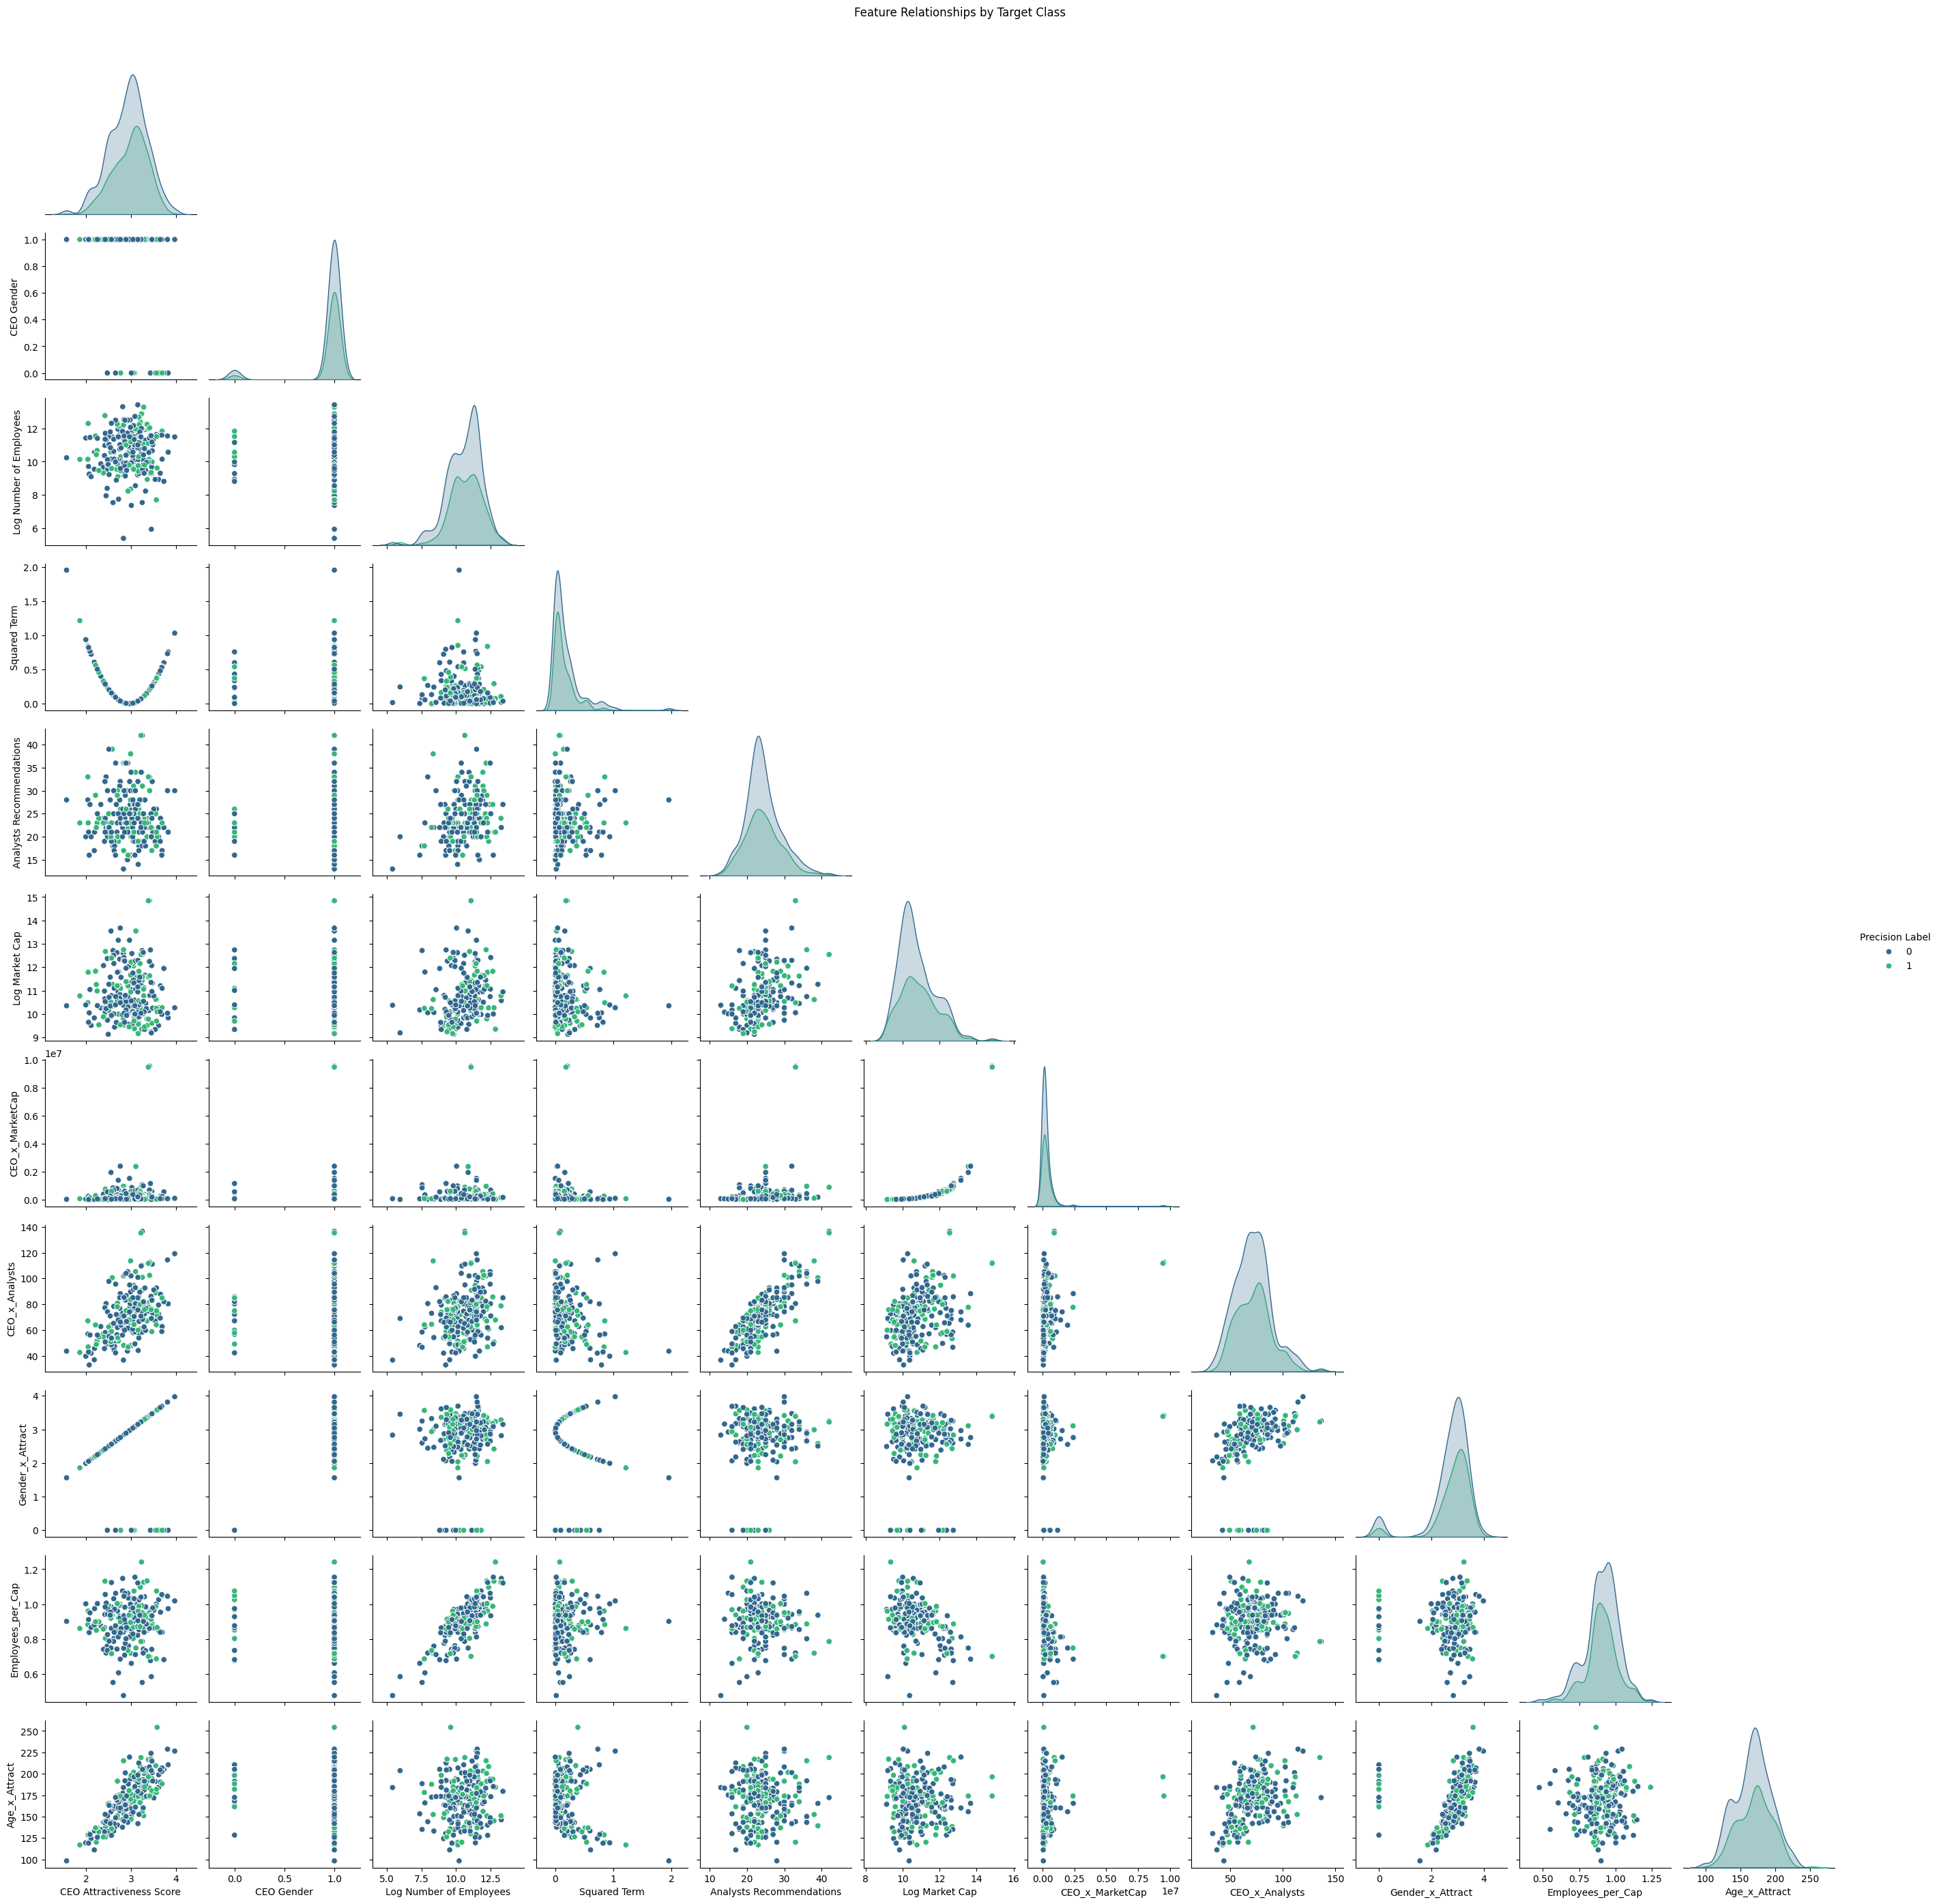

Applying SMOTE to training data...
Original training set shape: (1138, 11), (1138,)
SMOTE-resampled training set shape: (1454, 11), (1454,)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE # Import SMOTE


# Create interaction features
df['CEO_x_MarketCap'] = df['CEO Attractiveness Score'] * df['Market Cap Avg']
df['CEO_x_Analysts'] = df['CEO Attractiveness Score'] * df['Analysts Recommendations']
df['Gender_x_Attract'] = df['CEO Gender'] * df['CEO Attractiveness Score']
df['Employees_per_Cap'] = df['Log Number of Employees'] / (df['Log Market Cap'] + 1)
df['Age_x_Attract'] = df['Age'] * df['CEO Attractiveness Score']

# ALL features for modeling (original + engineered)
all_features = ['CEO Attractiveness Score', 'CEO Gender', 'Log Number of Employees',
               'Squared Term', 'Analysts Recommendations', 'Log Market Cap',
               'CEO_x_MarketCap', 'CEO_x_Analysts', 'Gender_x_Attract',
               'Employees_per_Cap', 'Age_x_Attract']

target = 'Precision Label'

# Create a temporary subset for visualization
viz_df = df[all_features + [target]].copy()

# Pairplot: Shows scatter plots of features colored by the target class
sns.pairplot(viz_df, hue=target, palette='viridis', corner=True)
plt.suptitle('Feature Relationships by Target Class', y=1.02)
plt.show()

# --- 3. Preprocessing ---
X = df[all_features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply SMOTE for imbalance (Replaced Class Weighting) ---
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training set shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"SMOTE-resampled training set shape: {X_train_smote.shape}, {y_train_smote.shape}")



--- Training RandomForestClassifier ---

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.80      0.79       168
           1       0.70      0.67      0.68       117

    accuracy                           0.74       285
   macro avg       0.74      0.73      0.73       285
weighted avg       0.74      0.74      0.74       285

ROC AUC Score: 0.7652

--- Lift Table (Top Deciles) ---
        Count  Response_Rate      Lift      Gain
decile                                          
1          28       0.750000  1.826923  0.179487
2          29       0.758621  1.847922  0.367521
3          29       0.689655  1.679929  0.538462
4          26       0.576923  1.405325  0.666667
5          29       0.172414  0.419982  0.709402


/tmp/ipython-input-2252435274.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lift_table.index, y='Lift', data=lift_table, ax=axes[0], palette="Blues_r")


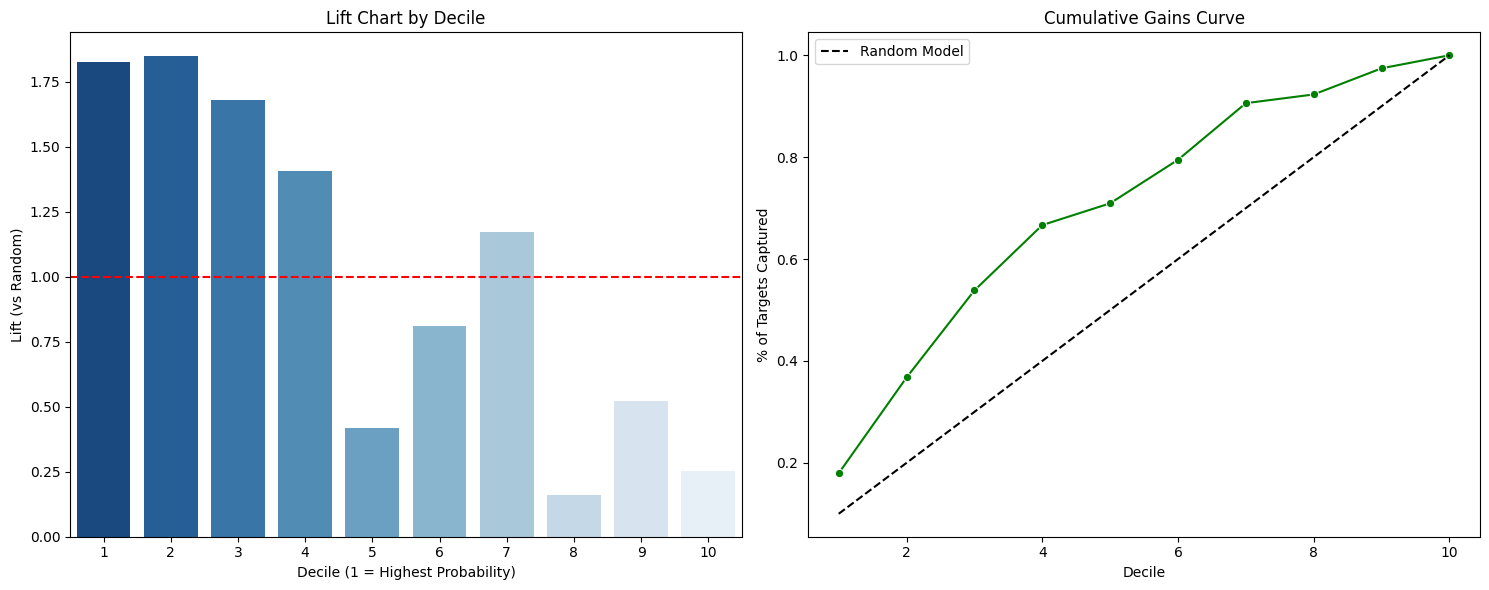

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# --- 4. Train RandomForestClassifier ---
print("\n--- Training RandomForestClassifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for potentially imbalanced test set
rf_model.fit(X_train_smote, y_train_smote)

# --- 5. Prediction & Metrics ---
predictions_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
predictions_label = rf_model.predict(X_test_scaled)

# Standard Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, predictions_label))
print(f"ROC AUC Score: {roc_auc_score(y_test, predictions_prob):.4f}")

# --- 6. LIFT & GAINS ANALYSIS ---
def calculate_lift(y_true, y_prob, n_bins=10):
    """
    Calculates Lift and Cumulative Gains.
    """
    # Create a DataFrame with actuals and probabilities
    data = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})

    # Sort by predicted probability (descending)
    data = data.sort_values(by='y_prob', ascending=False)

    # Create deciles
    data['decile'] = pd.qcut(data['y_prob'], q=n_bins, labels=False, duplicates='drop')
    data['decile'] = n_bins - data['decile'] # Flip so 1 is the top decile

    # Group by decile
    lift_df = data.groupby('decile').agg(
        Count=('y_true', 'count'),
        Responses=('y_true', 'sum')
    )

    # Calculate metrics
    total_response_rate = data['y_true'].mean()
    lift_df['Response_Rate'] = lift_df['Responses'] / lift_df['Count']
    lift_df['Lift'] = lift_df['Response_Rate'] / total_response_rate

    # Cumulative stats
    lift_df['Cum_Responses'] = lift_df['Responses'].cumsum()
    lift_df['Cum_Count'] = lift_df['Count'].cumsum()
    lift_df['Gain'] = lift_df['Cum_Responses'] / data['y_true'].sum()

    return lift_df

lift_table = calculate_lift(y_test, predictions_prob)

print("\n--- Lift Table (Top Deciles) ---")
print(lift_table[['Count', 'Response_Rate', 'Lift', 'Gain']].head())

# --- 7. Visualizing Performance & Lift ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Lift Chart
sns.barplot(x=lift_table.index, y='Lift', data=lift_table, ax=axes[0], palette="Blues_r")
axes[0].axhline(1.0, color='red', linestyle='--')
axes[0].set_title('Lift Chart by Decile')
axes[0].set_ylabel('Lift (vs Random)')
axes[0].set_xlabel('Decile (1 = Highest Probability)')

# Plot 2: Cumulative Gains
sns.lineplot(x=lift_table.index, y='Gain', data=lift_table, ax=axes[1], marker='o', color='green')
axes[1].plot([1, 10], [0.1, 1.0], 'k--', label='Random Model') # Diagonal line
axes[1].set_title('Cumulative Gains Curve')
axes[1].set_ylabel('% of Targets Captured')
axes[1].set_xlabel('Decile')
axes[1].legend()

plt.tight_layout()
plt.show()